In [1]:
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'nature', 'grid'])

import numpy as np
from scipy.interpolate import interp1d
import pandas as pd

from LoadMoments import *
from LoadTSV import *

In [2]:
WIDTH = 9.0#!6.0 
HEIGHT = 5.0

plt.rcParams.update({
    "figure.figsize": (WIDTH, HEIGHT),
    "font.size": 10,           # Matches thesis 10pt
    "axes.labelsize": 10,
    "legend.fontsize": 8,      # Slightly smaller for legends
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1,
    "lines.markersize": 4,
    "savefig.bbox": 'tight',   # Ensures no labels are cut off
    "savefig.pad_inches": 0.05
})

In [3]:
# Plotting
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']
linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 1))]

# Some first plots

In [4]:
# Parameter
M = 4
closure = "ExtGram"
Kn = 1.0
source_string = "relaxation_source"
T_end = 0.3
base_tree_level = 7
polydeg = 1
rho_L = 7.0
v_L1 = 0.0
v_L2 = 0.0
v_L3 = 0.0
theta_L = 1.0
rho_R = 1.0
v_R1 = 0.0
v_R2 = 0.0
v_R3 = 0.0
theta_R = 1.0
# name = f"../out/1D3D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L1{v_L1}_v_L2{v_L2}_v_L3{v_L3}_v_R1{v_R1}_v_R2{v_R2}_v_R3{v_R3}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}"
anglepair = 0 # default angle
name = f"../out/1D3D/1D3D_angles/gram_solution_1D3D_closure{closure}_Kn{Kn}_anglepairnumber{anglepair}_Tend{T_end}"

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_86892/2498118703.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


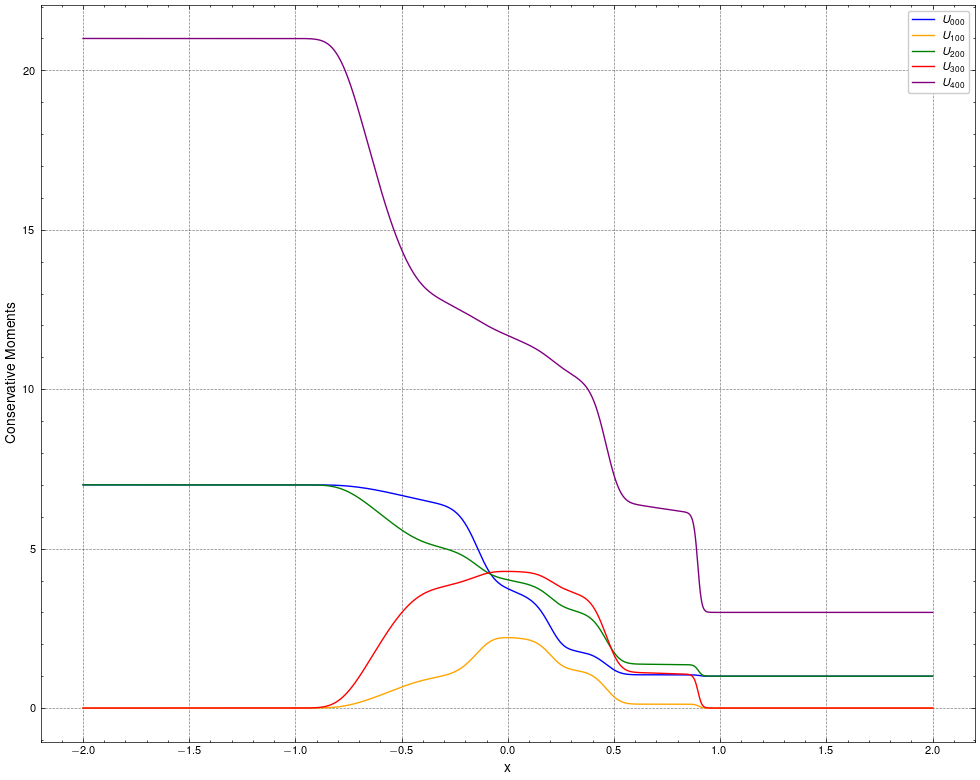

In [5]:
# Conservative Moments
data = read_solution_file(name + "_cons.tsv")

# Build time → timestep mapping
times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
timesteps = np.array(sorted(data.keys()))

time_query = 21 # last time step
sol = interpolate_solution(data, time_query, times, timesteps)
x, U, t = sol["x"], sol["u"], sol["t"]

fig, axs = plt.subplots(figsize=(10, 8))
axs.plot(x, U[:, 0], label="$U_{000}$", color=colors[0])
axs.plot(x, U[:, 1], label="$U_{100}$", color=colors[1])
axs.plot(x, U[:, 2], label="$U_{200}$", color=colors[2])
axs.plot(x, U[:, 4], label="$U_{300}$", color=colors[3])
axs.plot(x, U[:, 6], label="$U_{400}$", color=colors[4])
axs.set_xlabel("x")
axs.set_ylabel("Conservative Moments")
axs.grid(True)
axs.legend()
fig.tight_layout()
fig.savefig('../out/Figures/1D3D/ConservativeMoments.pdf')
fig.show()

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_86892/1207176404.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


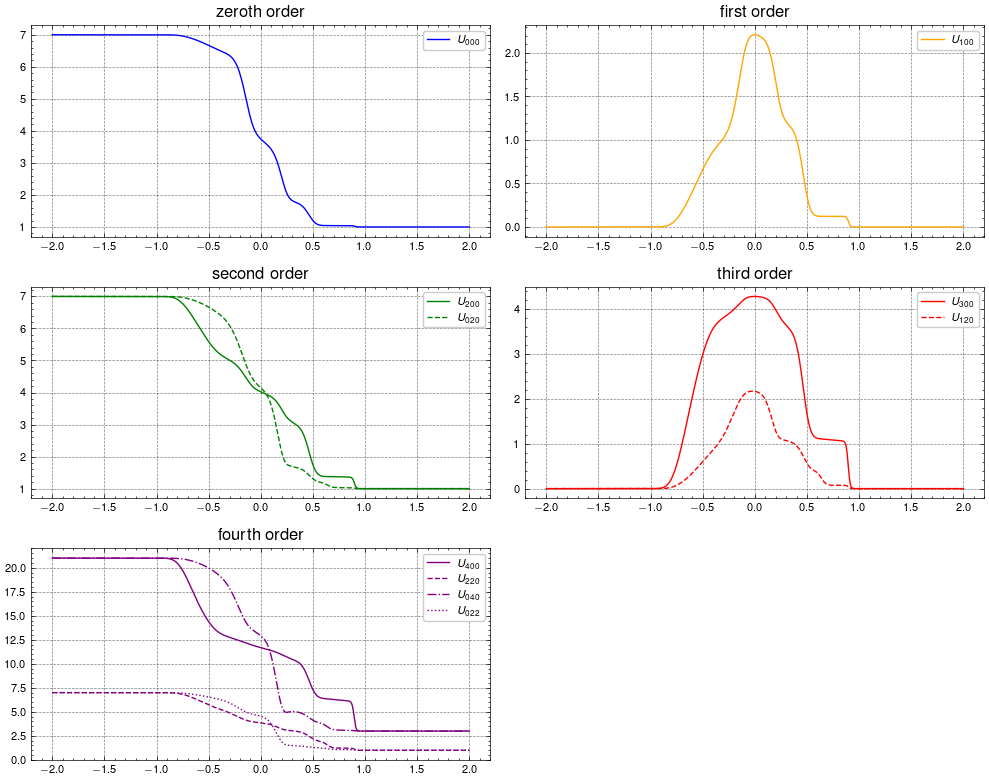

In [6]:
fig, axs = plt.subplots(3, 2, figsize=(10, 8))
axs[0, 0].plot(x, U[:, 0], label="$U_{000}$", color=colors[0], linestyle=linestyles[0])
axs[0, 0].set_title("zeroth order")
axs[0, 0].grid(True)
axs[0, 1].plot(x, U[:, 1], label="$U_{100}$", color=colors[1], linestyle=linestyles[0])
axs[0, 1].set_title("first order")
axs[0, 1].grid(True)
axs[1, 0].plot(x, U[:, 2], label="$U_{200}$", color=colors[2], linestyle=linestyles[0])
axs[1, 0].plot(x, U[:, 3], label="$U_{020}$", color=colors[2], linestyle=linestyles[1])
axs[1, 0].set_title("second order")
axs[1, 0].grid(True)
axs[1, 1].plot(x, U[:, 4], label="$U_{300}$", color=colors[3], linestyle=linestyles[0])
axs[1, 1].plot(x, U[:, 5], label="$U_{120}$", color=colors[3], linestyle=linestyles[1])
axs[1, 1].set_title("third order")
axs[1, 1].grid(True)
axs[2, 0].plot(x, U[:, 6], label="$U_{400}$", color=colors[4], linestyle=linestyles[0])
axs[2, 0].plot(x, U[:, 7], label="$U_{220}$", color=colors[4], linestyle=linestyles[1])
axs[2, 0].plot(x, U[:, 8], label="$U_{040}$", color=colors[4], linestyle=linestyles[2])
axs[2, 0].plot(x, U[:, 9], label="$U_{022}$", color=colors[4], linestyle=linestyles[3])
axs[2, 0].set_title("fourth order")
axs[2, 0].grid(True)
axs[2, 1].axis('off')
[ax.legend() for ax in axs.flat if ax.has_data()]
fig.tight_layout()
fig.savefig('../out/Figures/1D3D/ConservativeMoments_Full.pdf')
fig.show()

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_86892/1518321668.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


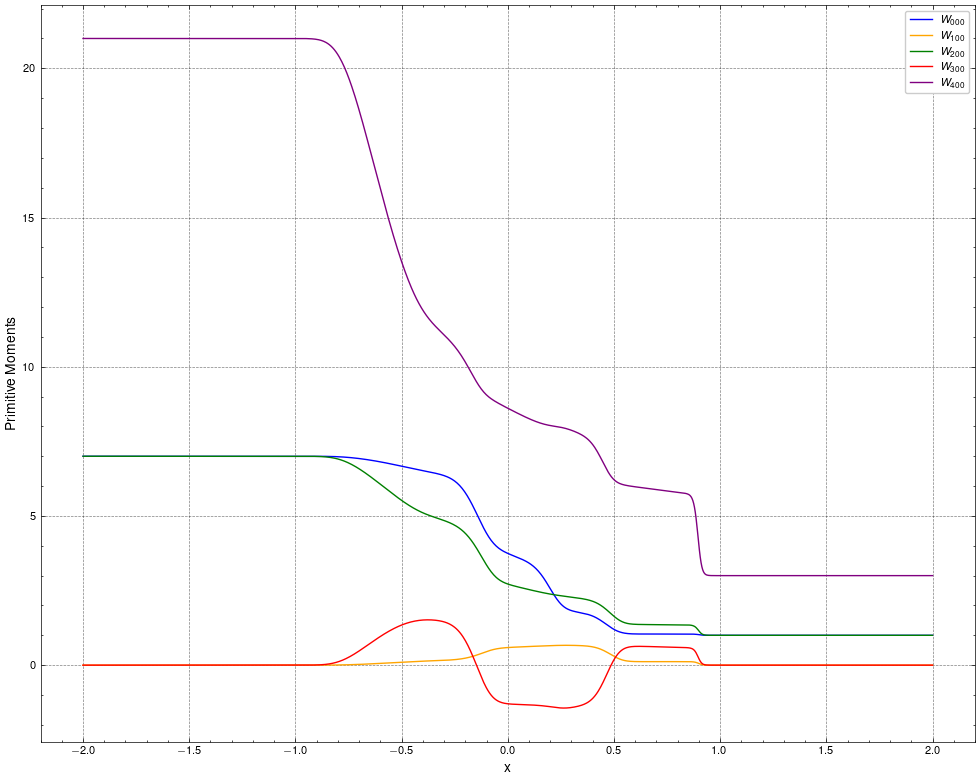

In [7]:
# Primitive Moments
data = read_solution_file(name + "_prim.tsv")

# Build time → timestep mapping
times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
timesteps = np.array(sorted(data.keys()))

time_query = 21 # last time step
sol = interpolate_solution(data, time_query, times, timesteps)
x, W, t = sol["x"], sol["u"], sol["t"]

fig, axs = plt.subplots(figsize=(10, 8))
axs.plot(x, W[:, 0], label="$W_{000}$", color=colors[0])
axs.plot(x, W[:, 1], label="$W_{100}$", color=colors[1])
axs.plot(x, W[:, 2], label="$W_{200}$", color=colors[2])
axs.plot(x, W[:, 4], label="$W_{300}$", color=colors[3])
axs.plot(x, W[:, 6], label="$W_{400}$", color=colors[4])
axs.set_xlabel("x")
axs.set_ylabel("Primitive Moments")
axs.grid(True)
axs.legend()
fig.tight_layout()
fig.savefig('../out/Figures/1D3D/PrimitiveMoments.pdf')
fig.show()

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_86892/2880951885.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


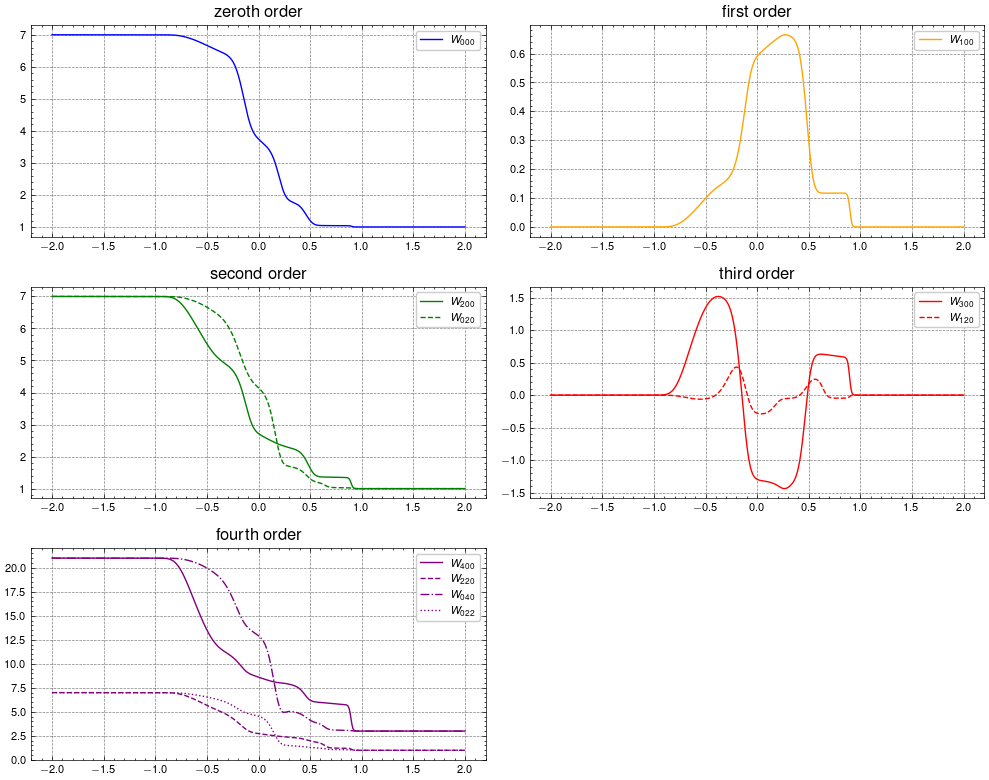

In [8]:
fig, axs = plt.subplots(3, 2, figsize=(10, 8))
axs[0, 0].plot(x, W[:, 0], label="$W_{000}$", color=colors[0], linestyle=linestyles[0])
axs[0, 0].set_title("zeroth order")
axs[0, 0].grid(True)
axs[0, 1].plot(x, W[:, 1], label="$W_{100}$", color=colors[1], linestyle=linestyles[0])
axs[0, 1].set_title("first order")
axs[0, 1].grid(True)
axs[1, 0].plot(x, W[:, 2], label="$W_{200}$", color=colors[2], linestyle=linestyles[0])
axs[1, 0].plot(x, W[:, 3], label="$W_{020}$", color=colors[2], linestyle=linestyles[1])
axs[1, 0].set_title("second order")
axs[1, 0].grid(True)
axs[1, 1].plot(x, W[:, 4], label="$W_{300}$", color=colors[3], linestyle=linestyles[0])
axs[1, 1].plot(x, W[:, 5], label="$W_{120}$", color=colors[3], linestyle=linestyles[1])
axs[1, 1].set_title("third order")
axs[1, 1].grid(True)
axs[2, 0].plot(x, W[:, 6], label="$W_{400}$", color=colors[4], linestyle=linestyles[0])
axs[2, 0].plot(x, W[:, 7], label="$W_{220}$", color=colors[4], linestyle=linestyles[1])
axs[2, 0].plot(x, W[:, 8], label="$W_{040}$", color=colors[4], linestyle=linestyles[2])
axs[2, 0].plot(x, W[:, 9], label="$W_{022}$", color=colors[4], linestyle=linestyles[3])
axs[2, 0].set_title("fourth order")
axs[2, 0].grid(True)
axs[2, 1].axis('off')
[ax.legend() for ax in axs.flat if ax.has_data()]
fig.tight_layout()
fig.savefig('../out/Figures/1D3D/PrimitiveMoments_Full.pdf')
fig.show()

## Compare 1D1D with 1D3D

In [9]:
source = "relaxation_source"
v_L = v_L1
v_R = v_R1
file_1D1D = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

x_1D1D, u_1D1D, _ = sol_final(file_1D1D)

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_86892/3300311430.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


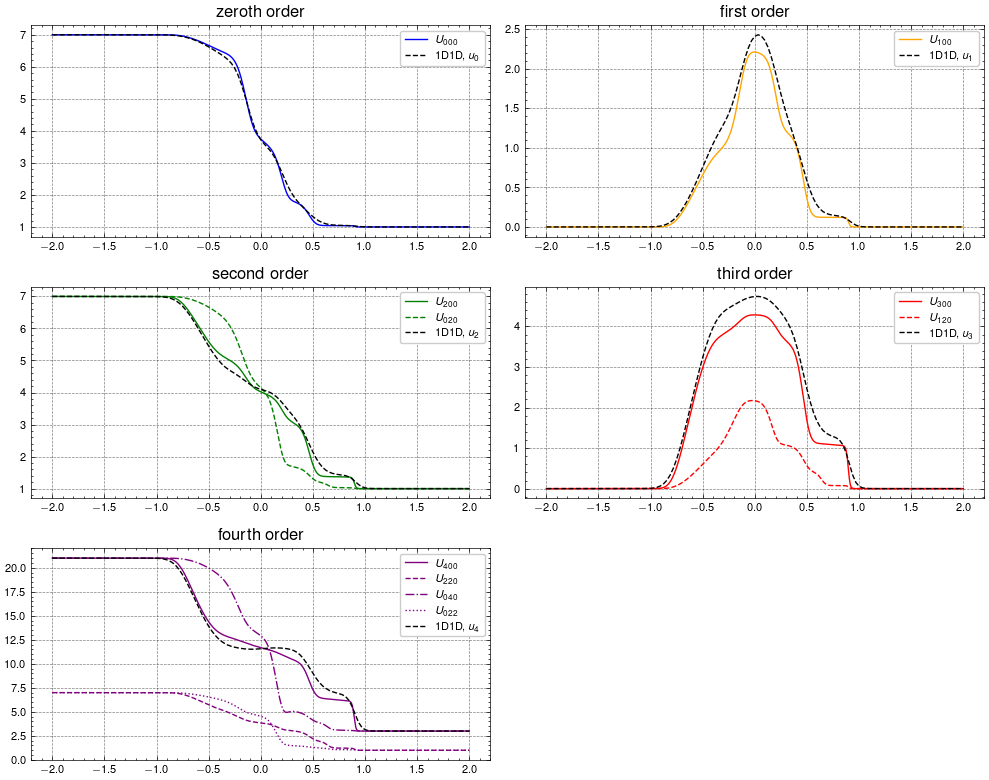

In [10]:
fig, axs = plt.subplots(3, 2, figsize=(10, 8))
axs[0, 0].plot(x, U[:, 0], label="$U_{000}$", color=colors[0], linestyle=linestyles[0])
axs[0, 0].plot(x_1D1D, u_1D1D[:, 0], label="1D1D, $u_{0}$", color='black', linestyle='dashed')
axs[0, 0].set_title("zeroth order")
axs[0, 0].grid(True)
axs[0, 1].plot(x, U[:, 1], label="$U_{100}$", color=colors[1], linestyle=linestyles[0])
axs[0, 1].plot(x_1D1D, u_1D1D[:, 1], label="1D1D, $u_{1}$", color='black', linestyle='dashed')
axs[0, 1].set_title("first order")
axs[0, 1].grid(True)
axs[1, 0].plot(x, U[:, 2], label="$U_{200}$", color=colors[2], linestyle=linestyles[0])
axs[1, 0].plot(x, U[:, 3], label="$U_{020}$", color=colors[2], linestyle=linestyles[1])
axs[1, 0].plot(x_1D1D, u_1D1D[:, 2], label="1D1D, $u_{2}$", color='black', linestyle='dashed')
axs[1, 0].set_title("second order")
axs[1, 0].grid(True)
axs[1, 1].plot(x, U[:, 4], label="$U_{300}$", color=colors[3], linestyle=linestyles[0])
axs[1, 1].plot(x, U[:, 5], label="$U_{120}$", color=colors[3], linestyle=linestyles[1])
axs[1, 1].plot(x_1D1D, u_1D1D[:, 3], label="1D1D, $u_{3}$", color='black', linestyle='dashed')
axs[1, 1].set_title("third order")
axs[1, 1].grid(True)
axs[2, 0].plot(x, U[:, 6], label="$U_{400}$", color=colors[4], linestyle=linestyles[0])
axs[2, 0].plot(x, U[:, 7], label="$U_{220}$", color=colors[4], linestyle=linestyles[1])
axs[2, 0].plot(x, U[:, 8], label="$U_{040}$", color=colors[4], linestyle=linestyles[2])
axs[2, 0].plot(x, U[:, 9], label="$U_{022}$", color=colors[4], linestyle=linestyles[3])
axs[2, 0].plot(x_1D1D, u_1D1D[:, 4], label="1D1D, $u_{4}$", color='black', linestyle='dashed')
axs[2, 0].set_title("fourth order")
axs[2, 0].grid(True)
axs[2, 1].axis('off')
[ax.legend() for ax in axs.flat if ax.has_data()]
fig.tight_layout()
fig.savefig('../out/Figures/1D3D/ConservativeMoments_Full.pdf')
fig.show()

# Different angle pairs

In [11]:
closure = 'ExtGram'
Kn = 1.0
T_end = 0.3
name = lambda anglepair: f"../out/1D3D/1D3D_angles/gram_solution_1D3D_closure{closure}_Kn{Kn}_anglepairnumber{anglepair}_Tend{T_end}_cons.tsv"

marker = ['o', 's', '^', 'x', 'd']

<>:25: SyntaxWarning: invalid escape sequence '\z'
<>:25: SyntaxWarning: invalid escape sequence '\z'
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_86892/2454522696.py:25: SyntaxWarning: invalid escape sequence '\z'
  [axs.plot([], [], color='black', linestyle=linestyles[i], label=f'$\zeta_{i+1}$') for i in range(4)]


Loaded data from ../out/1D3D/1D3D_angles/gram_solution_1D3D_closureExtGram_Kn1.0_anglepairnumber0_Tend0.3_cons.tsv
Loaded data from ../out/1D3D/1D3D_angles/gram_solution_1D3D_closureExtGram_Kn1.0_anglepairnumber1_Tend0.3_cons.tsv
Loaded data from ../out/1D3D/1D3D_angles/gram_solution_1D3D_closureExtGram_Kn1.0_anglepairnumber2_Tend0.3_cons.tsv
Loaded data from ../out/1D3D/1D3D_angles/gram_solution_1D3D_closureExtGram_Kn1.0_anglepairnumber3_Tend0.3_cons.tsv


/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_86892/2454522696.py:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


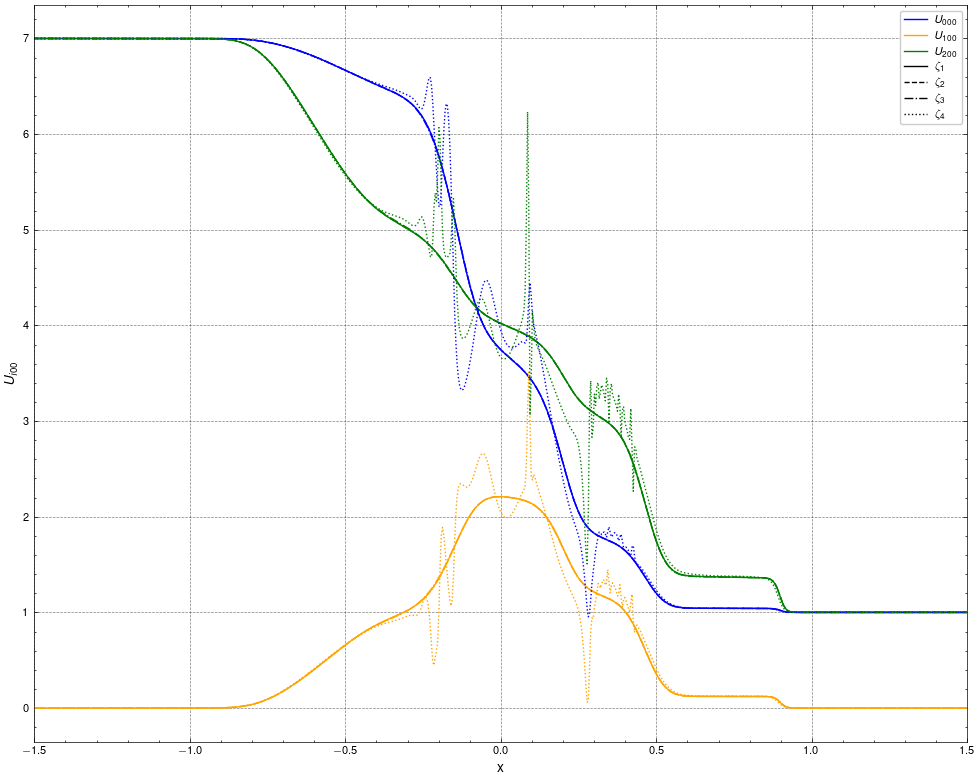

In [12]:
# Conservative Moments
fig, axs = plt.subplots(figsize=(10, 8))
# names = [name(i) for i in range(0,5)]
names = [name(0), name(1), name(2), name(3)]
for i, solution_file in enumerate(names):

    data = read_solution_file(solution_file)
    print(f"Loaded data from {solution_file}")

    # Build time → timestep mapping
    times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
    timesteps = np.array(sorted(data.keys()))

    time_query = 21 # last time step
    sol = interpolate_solution(data, time_query, times, timesteps)
    x, U, t = sol["x"], sol["u"], sol["t"]

    axs.plot(x, U[:, 0], color=colors[0], linestyle=linestyles[i])
    axs.plot(x, U[:, 1], color=colors[1], linestyle=linestyles[i])
    axs.plot(x, U[:, 2], color=colors[2], linestyle=linestyles[i])
    # axs.plot(x, U[:, 4], color=colors[3], linestyle=linestyles[i])
    # axs.plot(x, U[:, 6], color=colors[4], linestyle=linestyles[i])
labels = ['$U_{000}$', '$U_{100}$', '$U_{200}$']
[axs.plot([], [], color=colors[i], linestyle='-', label=label) for i, label in enumerate(labels)]
[axs.plot([], [], color='black', linestyle=linestyles[i], label=f'$\zeta_{i+1}$') for i in range(4)]
axs.set_xlabel("x")
axs.set_ylabel("$U_{i00}$")
axs.grid(True)
axs.legend()
axs.set_xlim(-1.5, 1.5)
fig.tight_layout()
fig.savefig('../out/Figures/1D3D/CompareAnglePairs.pdf')
fig.show()

<>:21: SyntaxWarning: invalid escape sequence '\z'
<>:22: SyntaxWarning: invalid escape sequence '\z'
<>:23: SyntaxWarning: invalid escape sequence '\z'
<>:21: SyntaxWarning: invalid escape sequence '\z'
<>:22: SyntaxWarning: invalid escape sequence '\z'
<>:23: SyntaxWarning: invalid escape sequence '\z'
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_86892/457232965.py:21: SyntaxWarning: invalid escape sequence '\z'
  axs[0].plot(x, U[:, 0], color=colors[i], linestyle=linestyles[i], label=f'$\zeta_{i+1}$')
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_86892/457232965.py:22: SyntaxWarning: invalid escape sequence '\z'
  axs[1].plot(x, U[:, 1], color=colors[i], linestyle=linestyles[i], label=f'$\zeta_{i+1}$')
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_86892/457232965.py:23: SyntaxWarning: invalid escape sequence '\z'
  axs[2].plot(x, U[:, 2], color=colors[i], linestyle=linestyles[i], label=f'$\zeta_{i+1}$')


Loaded data from ../out/1D3D/1D3D_angles/gram_solution_1D3D_closureExtGram_Kn1.0_anglepairnumber0_Tend0.3_cons.tsv
Loaded data from ../out/1D3D/1D3D_angles/gram_solution_1D3D_closureExtGram_Kn1.0_anglepairnumber1_Tend0.3_cons.tsv
Loaded data from ../out/1D3D/1D3D_angles/gram_solution_1D3D_closureExtGram_Kn1.0_anglepairnumber2_Tend0.3_cons.tsv
Loaded data from ../out/1D3D/1D3D_angles/gram_solution_1D3D_closureExtGram_Kn1.0_anglepairnumber3_Tend0.3_cons.tsv


/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_86892/457232965.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


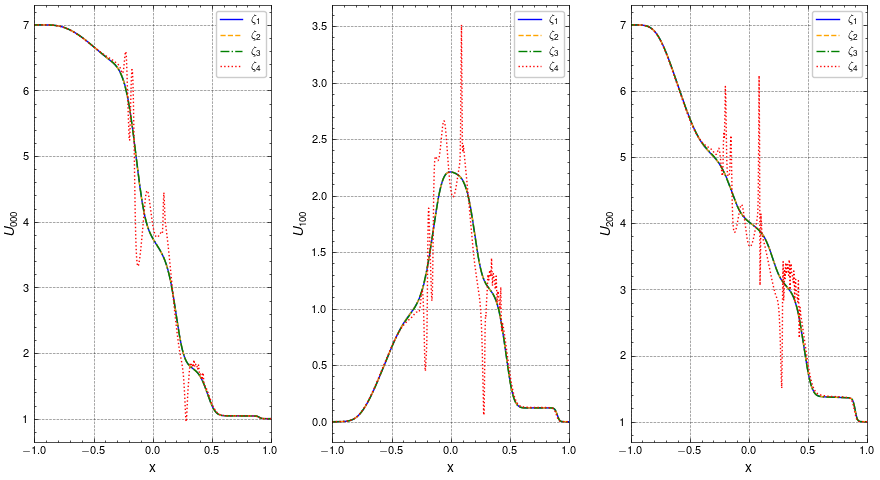

In [13]:
fig, axs = plt.subplots(1, 3)

[ax.set_xlim(-1, 1) for ax in axs]
[ax.set_xlabel('x') for ax in axs]
[ax.set_ylabel(label) for ax, label in zip(axs, ['$U_{000}$', '$U_{100}$', '$U_{200}$'])]

names = [name(0), name(1), name(2), name(3)]
for i, solution_file in enumerate(names):

    data = read_solution_file(solution_file)
    print(f"Loaded data from {solution_file}")

    # Build time → timestep mapping
    times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
    timesteps = np.array(sorted(data.keys()))

    time_query = 21 # last time step
    sol = interpolate_solution(data, time_query, times, timesteps)
    x, U, t = sol["x"], sol["u"], sol["t"]

    axs[0].plot(x, U[:, 0], color=colors[i], linestyle=linestyles[i], label=f'$\zeta_{i+1}$')
    axs[1].plot(x, U[:, 1], color=colors[i], linestyle=linestyles[i], label=f'$\zeta_{i+1}$')
    axs[2].plot(x, U[:, 2], color=colors[i], linestyle=linestyles[i], label=f'$\zeta_{i+1}$')

[ax.legend() for ax in axs]

fig.tight_layout()
fig.show()

In [14]:
M = 4
closure = "ExtGram"
Kn = 1.0
source_string = "relaxation_source"
T_end = 0.3
base_tree_level = 6
polydeg = 1

# Riemann
ρ_L = 7.0
v_L1 = 0.0
v_L2 = 0.0
v_L3 = 0.0
θ_L = 1.0
ρ_R = 1.0
v_R1 = 0.0
v_R2 = 0.0
v_R3 = 0.0
θ_R = 1.0

x_lower = -2.0
x_upper = 2.0

file = lambda anglepairnumber: f'../out/1D3D/1D3D_angles/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{ρ_L}_rho_R{ρ_R}_v_L1{v_L1}_v_L2{v_L2}_v_L3{v_L3}_v_R1{v_R1}_v_R2{v_R2}_v_R3{v_R3}_theta_L{θ_L}_theta_R{θ_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_anglepairnumber{anglepairnumber}_eigenvalues.csv'

anglepair: 0, eigenvalues: [-2.4494886026928473, -1.449137026067927, -0.9999993572725806, 1.9582434859335578e-07, 2.2867517851850279e-07, 2.3570210085084684e-07, 2.5467554105893933e-07, 1.000000269523414, 1.449137791696333, 2.44948974239445]
anglepair: 1, eigenvalues: [-2.449489769960063, -0.9999990898118785, 1.9864426335952919e-07, 2.191001772294229e-07, 2.191001772294229e-07, 2.5124809215312767e-07, 3.1690460538547634e-07, 5.278029341802318e-07, 1.000000057768497, 2.4494908722492896]
anglepair: 2, eigenvalues: [-2.449488602692811, -1.4491370203043892, -0.9999993572725633, 1.1731692647322245e-07, 1.8881290264837175e-07, 2.2867518769039865e-07, 2.9714348991813896e-07, 1.0000002695234211, 1.4491377931990859, 2.449489742394444]
anglepair: 3, eigenvalues: [-2.44948858893193, -1.0036382630328926, -0.9999988220030844, 1.9580981679801216e-07, 1.9580981679801216e-07, 2.151465741293218e-07, 2.291142861259628e-07, 0.999999736005095, 1.003639138631777, 2.4494897308265293]


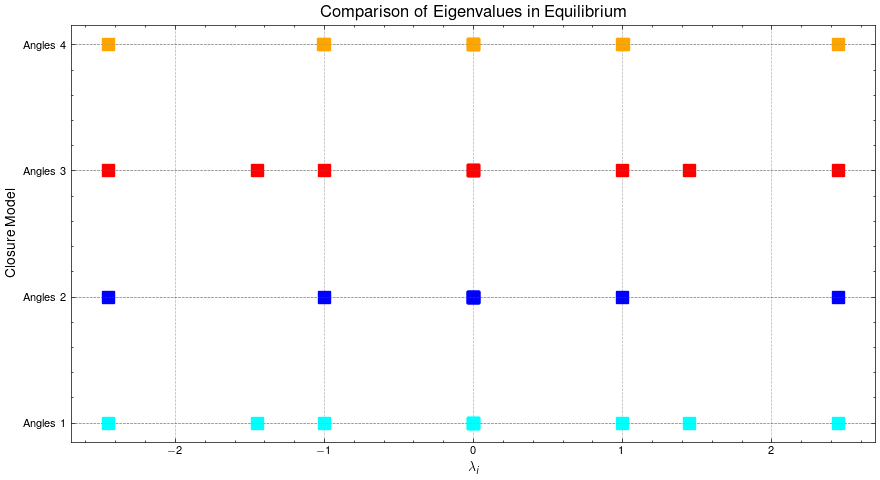

In [18]:
x_dest = -2.0

eigenvalues = []
for anglepair in range(4):
    data = pd.read_csv(file(anglepair))

    x_idx = (np.abs(data['x_vector'] - x_dest)).argmin()
    lambda_values_string = data['eigenvalue'][x_idx]
    lambda_values = [float(val) for val in lambda_values_string.strip('[]').split(',')]
    eigenvalues.append(lambda_values)

    print(f'anglepair: {anglepair}, eigenvalues: {lambda_values}')

angles = [
    (eigenvalues[0], 'cyan', 'Angles 1'),
    (eigenvalues[1], 'blue', 'Angles 2'),
    (eigenvalues[2], 'red', 'Angles 3'),
    (eigenvalues[3], 'orange', 'Angles 4')
]

plt.subplots()

for i, (lambda_values, color, label) in enumerate(angles):
    # Plot the eigenvalues as points at height 'i'
    plt.plot(lambda_values, [i] * len(lambda_values), 's', color=color, markersize=8, label=label)
    
    # Add a faint horizontal line to guide the eye for each category
    plt.axhline(i, color='gray', linestyle='--', linewidth=0.5, alpha=0.3)

# Set the y-ticks to match the index of the models and label them
plt.yticks(range(len(angles)), [m[2] for m in angles])

plt.xlabel('$\\lambda_i$')
plt.ylabel('Closure Model')
plt.title('Comparison of Eigenvalues in Equilibrium')
plt.grid(True, axis='x', alpha=0.3) # Grid only for x-axis to help read values

plt.tight_layout()
plt.show()


anglepair: 0, eigenvalues: [-1.9984587654056862, -0.9810949815406019, -0.581459589964907, 0.37761593607577026, 0.3807355366881431, 0.3807355366881431, 0.3870690819930323, 1.2488287423907691, 1.6792554784418237, 2.6124436479828987]
anglepair: 1, eigenvalues: [-2.0295735890712185, -0.5880688591677466, 0.25782854849524955, 0.3748457396037439, 0.38688176327421847, 0.3964959040167693, 0.4819410361042195, 0.4819410361042195, 1.2232468629337465, 2.6650288330663083]
anglepair: 2, eigenvalues: [-1.9984589288925991, -0.9836723872516684, -0.5814596240825562, 0.37063363631266005, 0.3856562715842671, 0.3870690925617009, 0.3957280829928841, 1.2488288098447018, 1.679421628694342, 2.6124438528299843]
anglepair: 3, eigenvalues: [-1.9979459127070571, -0.5812520712350846, -0.5561692614949764, 0.3870786870474909, 0.39475433635217605, 0.39710117433365366, 0.41701239082212777, 1.2352109671544627, 1.248830014332925, 2.612234117482589]


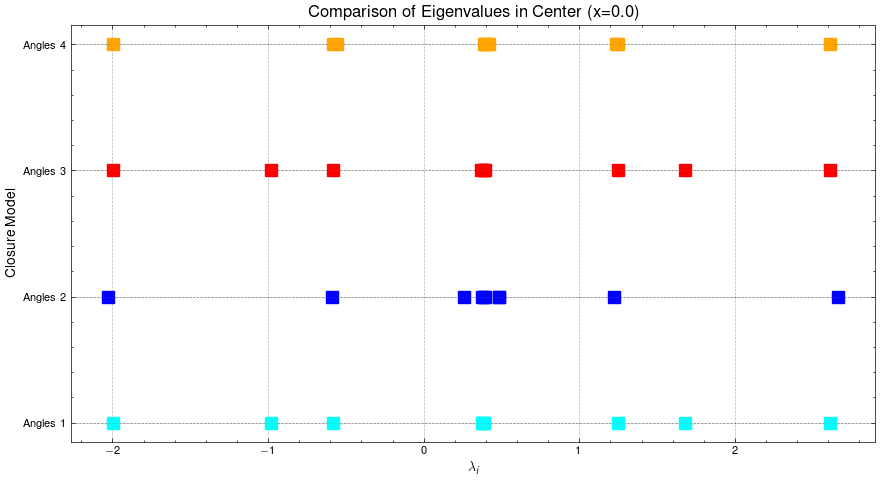

In [19]:
x_dest = 0.0

eigenvalues = []
for anglepair in range(4):
    data = pd.read_csv(file(anglepair))

    x_idx = (np.abs(data['x_vector'] - x_dest)).argmin()
    lambda_values_string = data['eigenvalue'][x_idx]
    lambda_values = [float(val) for val in lambda_values_string.strip('[]').split(',')]
    eigenvalues.append(lambda_values)

    print(f'anglepair: {anglepair}, eigenvalues: {lambda_values}')

angles = [
    (eigenvalues[0], 'cyan', 'Angles 1'),
    (eigenvalues[1], 'blue', 'Angles 2'),
    (eigenvalues[2], 'red', 'Angles 3'),
    (eigenvalues[3], 'orange', 'Angles 4')
]

plt.subplots()

for i, (lambda_values, color, label) in enumerate(angles):
    # Plot the eigenvalues as points at height 'i'
    plt.plot(lambda_values, [i] * len(lambda_values), 's', color=color, markersize=8, label=label)
    
    # Add a faint horizontal line to guide the eye for each category
    plt.axhline(i, color='gray', linestyle='--', linewidth=0.5, alpha=0.3)

# Set the y-ticks to match the index of the models and label them
plt.yticks(range(len(angles)), [m[2] for m in angles])

plt.xlabel('$\\lambda_i$')
plt.ylabel('Closure Model')
plt.title(f'Comparison of Eigenvalues in Center (x={x_dest})')
plt.grid(True, axis='x', alpha=0.3) # Grid only for x-axis to help read values

plt.tight_layout()
plt.show()
